# FORMATIVE ASSESSMENT OF ADOLESCENT GIRLS AND YOUNG WOMEN’S HIV, GENDER-BASED VIOLENCE AND SEXUAL AND REPRODUCTIVE HEALTH STATUS

## Background
Teenage pregnancy and motherhood have been a major health and social concern in Uganda as it infringes upon the human rights of girls but also hinders their ability to achieve their full socioeconomic development. Teenagers who engage in sexual intercourse at a young age face an elevated risk of becoming pregnant and giving birth. The 2022 UDHS indicated that 23.5% of women age 15-19 had initiated childbearing by the time of the survey, with 18.4% having already had a live birth, while 5.1% were pregnant with their first child.

Patterns by background characteristics:
* By age 16, 1 in every 10 women age 15-19 has begun childbearing. This percentage significantly rises to almost 4 out of every 10 by the time they reach 18 (Table 5.12).
* Teenagers in rural areas started childbearing earlier than those in urban areas. Twenty five percent of women age 15-19 in rural areas have begun childbearing, compared with 21% in urban areas.
* Teenage childbearing varies by region. The percentage of women age 15-19 who have begun childbearing ranges from 15% in Kigezi region to 28 % -30% in Busoga and Bukedi sub regions.
* The proportion of women age 15-19 who have begun childbearing decreases with both education and wealth.

Regions: The selection of the districts that we surveyed was informed by HIV prevalence dynamics and implementing partner support: we went to districts where there were Global Fund-supported implementing partners working to reduce the new number of new HIV infections among AGYW, improve SRH (e.g. reduce teenage pregnancy) and GBV indicators in the targeted districts.

## Data Processing

The output of this notebook includes four cleaned data frames, ready for further analysis.

## Load dataset

In [273]:
# File paths [update with your file path]
data_path = (
    '/Users/nataschajademinnitt/Documents/5. Data Analysis/unicef_teenage_preg/data/'
)

figures_path_15_19 = (
    '/Users/nataschajademinnitt/Documents/5. Data Analysis/unicef_teenage_preg/results/figures/profiling/girls_15_19/'
)

figures_path_10_14 = (
    '/Users/nataschajademinnitt/Documents/5. Data Analysis/unicef_teenage_preg/results/figures/profiling/girls_10_14/'
)

In [275]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf

# Set environment
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style="whitegrid", context="paper")

# Load the Stata file (.dta)
df_clean = pd.read_csv(data_path + "processed_df.csv")

# Validate cohort assignments
print(df_clean.groupby(['cohort_1', 'been_preg']).size().reset_index(name='count'))
print(df_clean.groupby(['cohort_2', 'been_preg']).size().reset_index(name='count'))

   cohort_1  been_preg  count
0     10-14          0   1250
1     10-14          1     25
2     15-19          0   3010
3     15-19          1    898
4     20-24          0   1402
5     20-24          1    939
6  Below 10          0     11
   cohort_2  been_preg  count
0     10-14          0   1250
1     10-14          1    125
2     15-19          0   3010
3     15-19          1   1800
4     20-24          0   1402
5  Below 10          0     11


In [277]:
check = df_clean[(df_clean['cohort_2'] == '10-14') | (df_clean['cohort_2'] == '15-19')].copy()
check['been_married_binary'].value_counts()

been_married_binary
0    4842
1    1343
Name: count, dtype: int64

In [279]:
check = df_clean[(df_clean['cohort_2'] == '10-14') | (df_clean['cohort_2'] == '15-19')].copy()
check = check[check["person_sex"] == 2]
check['cohort_2_bin'] = check['cohort_2'].map({'10-14': 0, '15-19': 1})

## Overall

In [281]:
# Create contingency table for cohort_2_bin by will_sex_binary
contingency_table = pd.crosstab(check['cohort_2_bin'], check['will_sex_binary'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square test statistic: {chi2:.2f}, p-value: {p:.4f}")

# Fit a logistic regression model with will_sex_binary as a categorical predictor
logit_model = smf.logit("will_sex_binary ~ C(cohort_2_bin)", data=check).fit()
print(logit_model.summary())

Chi-square test statistic: 5.61, p-value: 0.0178
Optimization terminated successfully.
         Current function value: 0.486302
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:        will_sex_binary   No. Observations:                  368
Model:                          Logit   Df Residuals:                      366
Method:                           MLE   Df Model:                            1
Date:                Tue, 25 Feb 2025   Pseudo R-squ.:                 0.01621
Time:                        19:10:45   Log-Likelihood:                -178.96
converged:                       True   LL-Null:                       -181.91
Covariance Type:            nonrobust   LLR p-value:                   0.01516
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.1335      0.

In [285]:
# Willingness by type of partner
willing_mapping = {1.00: "Willing", 0.00: "Not willing"}
df_clean['will_sex_binary_mapped'] = df_clean['will_sex_binary'].map(willing_mapping)
print(df_clean['will_sex_binary_mapped'].value_counts())

will_sex_binary_mapped
Willing        2851
Not willing    1123
Name: count, dtype: int64


In [287]:
df_clean.do_anything.value_counts()

do_anything
1.00    1947
2.00    1850
3.00      38
Name: count, dtype: int64

In [291]:
anything_mapping = {1.00: 1.00, 0.00: 2.00, 0.00:3.00}
df_clean['do_anything_mapped'] = df_clean['do_anything'].map(anything_mapping)
print(df_clean['do_anything_mapped'].value_counts())

do_anything_mapped
1.00    1947
Name: count, dtype: int64


## Profiling Girls 10 - 14

In [380]:
# Girls age 10 - 14 cohort 1 (time-sensitive) -> girls who fell pregnant within 2 years of 10 - 14 (proximiate)
df_sensitive = df_clean[(df_clean['cohort_1'] == '10-14') & (df_clean['been_preg'] == 1)].copy()

# Girls age 10 - 14 cohort 2 (time-insensitive) -> girls who fell pregnant within 2 years of 10 - 14 (distant)
df_insensitive = df_clean[(df_clean['cohort_2'] == '10-14') & (df_clean['been_preg'] == 1)].copy()

### Schooling

In [374]:
# Calculate the total number of girls in the dataset
total_girls = len(df_sensitive)

# Determine the number and percentage of girls who are out of school
out_of_school_count = df_sensitive['scol_status'].value_counts().get('Out of school', 0)
out_of_school_percent_total = out_of_school_count / total_girls

# Create a subset of girls who are out of school
df_out = df_sensitive[df_sensitive['scol_status'] == 'Out of school']

# Among out-of-school girls, count those who had attended school before (i.e. dropped out)
dropped_out_count = df_out['attend_scol'].value_counts().get('Yes', 0)
dropped_out_percent_out = dropped_out_count / out_of_school_count if out_of_school_count else 0

# Among out-of-school girls, count those who never attended school
never_attended_count = df_out['attend_scol'].value_counts().get('No', 0)
never_attended_percent_out = never_attended_count / out_of_school_count if out_of_school_count else 0

# Print a clear summary message
print(f"Out of a total sample of {total_girls} girls, {out_of_school_count} ({out_of_school_percent_total:.1%}) are out of school.")
print(f"Among these out-of-school girls, {dropped_out_count} ({dropped_out_percent_out:.1%}) had attended school previously and then dropped out, "
      f"while {never_attended_count} ({never_attended_percent_out:.1%}) never attended school.")

Out of a total sample of 25 girls, 24 (96.0%) are out of school.
Among these out-of-school girls, 20 (83.3%) had attended school previously and then dropped out, while 4 (16.7%) never attended school.


In [376]:
# What are some of the main reasons you are not in school?
count = df_sensitive.loc[(df_sensitive['attend_scol'] == 'Yes') & (df_sensitive['scol_status'] == 'Out of school') & (df_sensitive['lack_fees'] == 1)]
count.level_scol.value_counts()

level_scol
PRIMARY (P.1 –P.7)      11
O’ LEVEL (S.1 – S.4)     1
PRIMARY PROFESSIONAL     1
Name: count, dtype: int64

The most common reason for dropping out is due to a Lack of fees, uniform or materials (13 mentions).
The second most common reason for dropping out is Got pregnant (6  mentions).


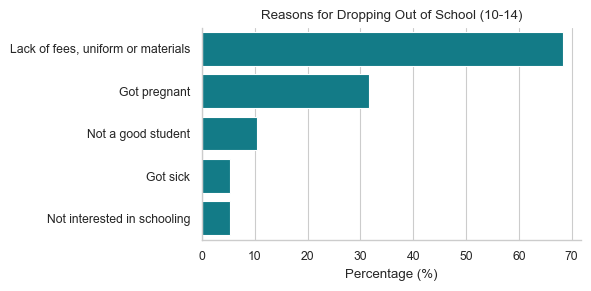

In [378]:
# What are some of the main reasons you are not in school?
count = df_sensitive.loc[(df_sensitive['attend_scol'] == 'Yes') & (df_sensitive['scol_status'] == 'Out of school')]

# Define dropout reasons
dropout_reasons = ['lack_fees', 'got_preg', 'got_married', 'got_sick', 'need_money', 'good_std', 'int_scol']

# Calculate count for each dropout reason
count_reasons_drop_out = count[dropout_reasons].apply(lambda col: (col == 1).sum()).to_frame(name='Count')
total_individuals = (count[dropout_reasons] == 1).any(axis=1).sum()

# Correct proportions by dividing by unique individuals
count_reasons_drop_out['Proportion'] = count_reasons_drop_out['Count'] / total_individuals

# Define mapping for dropout reasons with proper capitalization
dropout_labels = {
    'lack_fees': "Lack of fees, uniform or materials",
    'got_preg': "Got pregnant",
    'got_married': "Got married",
    'got_sick': "Got sick",
    'need_money': "Need money",
    'good_std': "Not a good student",
    'int_scol': "Not interested in schooling"
}

# Reset index to turn the index into a column
count_reasons_drop_out = count_reasons_drop_out.reset_index()

# Rename columns
count_reasons_drop_out.columns = ['Reason', 'Count', 'Proportion']

# Map the 'Reason' to descriptive labels
count_reasons_drop_out['Reason'] = count_reasons_drop_out['Reason'].map(dropout_labels).fillna("Unknown")

# Calculate percentage
count_reasons_drop_out['Percentage'] = (count_reasons_drop_out['Proportion'] * 100).round(1)

# Sort by Count descending
count_reasons_drop_out = count_reasons_drop_out.sort_values(by="Count", ascending=False)

count_reasons_drop_out = count_reasons_drop_out[count_reasons_drop_out['Count'] > 0]

# # Extract the first row details
first_row_id = count_reasons_drop_out.iloc[0]['Reason']
first_row_count = count_reasons_drop_out.iloc[0]['Count']
first_row_percentage = count_reasons_drop_out.iloc[0]['Proportion']

second_row_id = count_reasons_drop_out.iloc[1]['Reason']
second_row_count = count_reasons_drop_out.iloc[1]['Count']
second_row_percentage = count_reasons_drop_out.iloc[1]['Proportion']

# Display extracted values
print(f"The most common reason for dropping out is due to a {first_row_id} ({first_row_count} mentions).")
print(f"The second most common reason for dropping out is {second_row_id} ({second_row_count}  mentions).")

# Plot
plt.figure(figsize=(6, 3))
sns.barplot(x="Percentage", y="Reason", data=count_reasons_drop_out, color="#008b9a")
plt.xlabel("Percentage (%)")
plt.ylabel("")
plt.title("Reasons for Dropping Out of School (10-14)")
sns.despine(top=True, right=True)
plt.tight_layout()
plt.savefig(figures_path_10_14 + 'reasons_for_dropping_out_10_14.png', dpi=300)
plt.show()

In [ ]:
# If there was an opportunity for you to return to school, would you be willing to do so?
df = df_sensitive.loc[(df_sensitive['scol_status'] == 'Out of school') & (df_sensitive['got_preg'] == 1)]
count = df['return_scol'].value_counts()
percent = df['return_scol'].value_counts(normalize=True)

# Extract the proportion of 'yes' == 1 responses
count = count.get('Yes', 0)
percent = percent.get('Yes', 0)

print(f"Among the girls who mentioned pregnancy as the reason for dropping out, {count} would like to return to school if the opportunity arises.")

### Household situation

In [341]:
# Number of girls by wealth tertile
vulnerable_count = df_sensitive['wealth_tertile'].value_counts()
vulnerable_percent = df_sensitive['wealth_tertile'].value_counts(normalize=True)

# Extract the proportion of 'Low'
vulnerable_count = vulnerable_count.get('Low', 0)
vulnerable_percent = vulnerable_percent.get('Low', 0)

print(f"The proportion of girls living in low-income households is {vulnerable_percent:.1%} ({vulnerable_count}).")

The proportion of girls living in low-income households is 64.0% (16).


In [343]:
# Number of girls living in vulnerable households
vulnerable_count = df_sensitive['hh_vul'].value_counts()
vulnerable_percent = df_sensitive['hh_vul'].value_counts(normalize=True)

# Extract the proportion of 'yes' == 1 responses
vulnerable_count = vulnerable_count.get(1, 0)
vulnerable_percent = vulnerable_percent.get(1, 0)

print(f"The proportion of girls living in vulnerable households is {vulnerable_percent:.1%} ({vulnerable_count}).")

The proportion of girls living in vulnerable households is 16.0% (4).


In [345]:
# What is your main occupation, where you spend most of your time?
labels = {
    'PEASANT FARMER': "Peasant farmer",
    'SALARIED': "Salaried",
    'BUSINESS/COMMERCIAL': "Business/commercial",
    'CASUAL WORKER': "Casual worker",
    'HOUSE WIFE': "Housewife",
    'PUPIL/STUDENT/NO INCOME': "Pupil/student",
    'OTHER': "Other"
}

# Calculate raw counts for each occupation
raw_counts = df_sensitive["main_occup"].value_counts().reset_index()
raw_counts.columns = ["Occupation", "Count"]

# Map occupation codes to descriptive labels
raw_counts["Occupation"] = raw_counts["Occupation"].map(labels)

# Calculate percentage for each occupation
total = raw_counts["Count"].sum()
raw_counts["Percentage"] = (raw_counts["Count"] / total) * 100

# Sort the DataFrame by Count in descending order
raw_counts = raw_counts.sort_values(by="Count", ascending=False)

# Round the Percentage to two decimal places for clarity
raw_counts["Percentage"] = raw_counts["Percentage"].round(1)

# Reset index for a clean table
raw_counts.reset_index(drop=True, inplace=True)

# Extract the first row details
first_row_id = raw_counts.iloc[0]['Occupation']
first_row_count = raw_counts.iloc[0]['Count']
first_row_percentage = raw_counts.iloc[0]['Percentage']

second_row_id = raw_counts.iloc[1]['Occupation']
second_row_count = raw_counts.iloc[1]['Count']
second_row_percentage = raw_counts.iloc[1]['Percentage']

# Display
print(f"In response to the question ‘what is your main occupation, where you spend most of your time?’ most girls mentioned {first_row_id}, {first_row_percentage}% ({first_row_count}),")
print(f"followed by {second_row_id}, {second_row_percentage}% ({second_row_count}).")

In response to the question ‘what is your main occupation, where you spend most of your time?’ most girls mentioned Peasant farmer, 44.0% (11),
followed by Other, 24.0% (6).


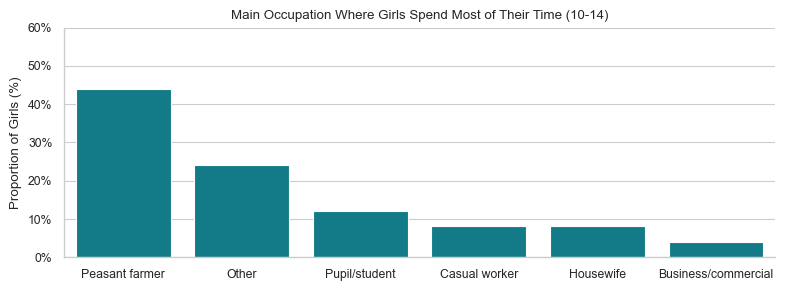

In [351]:
# Visualise main occupation
occup_counts = df_sensitive["main_occup"].value_counts(normalize=True).reset_index()
occup_counts.columns = ["Occupation", "Count"]

# Replace numerical values with category names
occup_counts["Occupation"] = occup_counts["Occupation"].map(labels)

# Convert proportion to percentage
occup_counts["Count"] *= 100

# Ensure Count column is numeric before sorting
occup_counts["Count"] = pd.to_numeric(occup_counts["Count"], errors='coerce')

# Sort values in descending order
occup_counts = occup_counts.sort_values(by="Count", ascending=False)

# Extract the ordered list of occupations
ordered_occupations = occup_counts["Occupation"]

# Plot
plt.figure(figsize=(8, 3))
sns.barplot(
    y="Count",
    x="Occupation",
    data=occup_counts,
    color="#008b9a",
    order=ordered_occupations
)

# Labels and title
plt.ylabel("Proportion of Girls (%)")
plt.xlabel("")
plt.title("Main Occupation Where Girls Spend Most of Their Time (10-14)")

# Remove top and right spines
sns.despine(top=True, right=True)

# Remove grid lines on y-axis
plt.grid(False, axis='x')

# Set custom x-ticks
plt.yticks(
    ticks=[0, 10, 20, 30, 40, 50, 60],
    labels=['0%', '10%', '20%', '30%', '40%', '50%', '60%']
)

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig(figures_path_10_14 + 'main_occupation_10_14.png')
plt.show()

In [ ]:
# Who do you currently live with?
person_labels = {
    'ALONE': "alone",
    'FRIENDS': "friends",
    'MOTHER ALONE': "mother alone",
    'FATHER ALONE': "father alone",
    'BOTH PARENTS': "both parents",
    'WITH OTHER RELATIVES': "with other relatives",
    'HUSBAND/PARTNER': "husband/partner"
}

# Calculate raw counts for each person_sex category
raw_counts = df_sensitive["who_live"].value_counts().reset_index()
raw_counts.columns = ["Person", "Count"]

# Map person_sex codes to descriptive labels
raw_counts["Person"] = raw_counts["Person"].map(person_labels)

# Calculate percentage for each person category
total = raw_counts["Count"].sum()
raw_counts["Percentage"] = (raw_counts["Count"] / total) * 100

# Sort the DataFrame by Count in descending order
raw_counts = raw_counts.sort_values(by="Count", ascending=False)

# Round the Percentage to one decimal place for clarity
raw_counts["Percentage"] = raw_counts["Percentage"].round(1)

# Reset index for a clean table
raw_counts.reset_index(drop=True, inplace=True)

# Extract the first row details
first_row_id = raw_counts.iloc[0]['Person']
first_row_count = raw_counts.iloc[0]['Count']
first_row_percentage = raw_counts.iloc[0]['Percentage']

# Extract the second row details
second_row_id = raw_counts.iloc[1]['Person']
second_row_count = raw_counts.iloc[1]['Count']
second_row_percentage = raw_counts.iloc[1]['Percentage']

# Display extracted values
print(f"Girls mainly live with their {first_row_id}, {first_row_percentage}% ({first_row_count}), and then {second_row_id}, {second_row_percentage}% ({second_row_count}).")

### Marriage

In [382]:
# Have you ever been married?
been_marriage_count = df_insensitive['been_married_binary'].value_counts()
been_marriage_percent = df_insensitive['been_married_binary'].value_counts(normalize=True)

# Extract the proportion of 'yes' == 1 responses
been_marriage_count = been_marriage_count.get(1, 0)
been_marriage_percent = been_marriage_percent.get(1, 0)

# Are you currently married?
marriage_count = df_insensitive['current_married_binary'].value_counts()
marriage_percent = df_insensitive['current_married_binary'].value_counts(normalize=True)

# Extract the proportion of 'yes' == 1 responses
marriage_count = marriage_count.get(1, 0)
marriage_percent = marriage_percent.get(1, 0)

print(f"The proportion of girls who have ever been married is {been_marriage_percent:.1%} ({been_marriage_count}) and the proportion of girls currently married is {marriage_percent:.1%} ({marriage_count}).")

The proportion of girls who have ever been married is 68.0% (85) and the proportion of girls currently married is 48.0% (60).


In [384]:
df_insensitive['current_married'].value_counts()

current_married
MARRIED/UNION                      60
DIVORCED/SEPARATED                 24
NEVER MARRIED                      23
IN RELATIONSHIP BUT NOT MARRIED    17
WIDOWED                             1
Name: count, dtype: int64

Most girls who married and experienced pregnancy between 10-14 years got married at 0    14
Name: age_marry, dtype: int64 years.


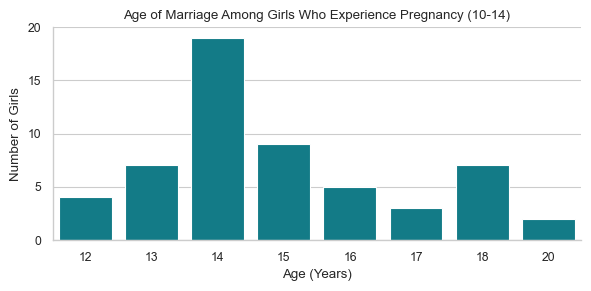

In [386]:
# How old were you when you first got married?
df_pro = df_insensitive[df_insensitive['been_married_binary'] == 1].copy()

# Remove rows with missing age_marry before converting to int
df_pro = df_pro[df_pro['age_marry'].notna()].copy()
df_pro['age_marry'] = df_pro['age_marry'].astype(int)
df_pro = df_pro[df_pro['age_completed'] >= 19]

# Age of Marriage Among Girls Who Experience Pregnancy
mean_age = df_pro['age_marry'].mode().round()
print(f"Most girls who married and experienced pregnancy between 10-14 years got married at {mean_age} years.")

plt.figure(figsize=(6, 3))
ax = sns.countplot(x='age_marry', data=df_pro, color='#008b9a')
plt.xlabel("Age (Years)")
plt.ylabel("Number of Girls")
plt.title("Age of Marriage Among Girls Who Experience Pregnancy (10-14)")
sns.despine(top=True, right=True)

y_max = ax.get_ylim()[1]
plt.yticks(range(0, int(y_max) + 5, 5))

plt.tight_layout()
plt.savefig(figures_path_10_14 + 'age_marriage_10_14.png', dpi=300)
plt.show()

### Sexual Debut

In [ ]:
# Age of Sexual Debut Among Girls Who Experience Pregnancy
mean = df_insensitive.sex_age.mean().round()

print(f"On average girls who fall pregnant between 10 and 14 had their sexual debut at {mean} years.")


plt.figure(figsize=(8, 5))
plt.hist(df_insensitive['sex_age'].dropna(), bins=7, color='#008b9a')

plt.xlabel("Age (Years)")
plt.ylabel("Number of Girls")
plt.title("Age of Sexual Debut Among Girls Who Experience Pregnancy (10-14)", fontsize=12)
sns.despine(top=True, right=True)
plt.grid(False, axis='x')

plt.tight_layout()
plt.savefig(figures_path_10_14 + 'age_sexual_debut_preg_10_14.png', dpi=300)
plt.show()

In [ ]:
# Distribution of Time Between Sexual Debut and Pregnancy
df_insensitive['time_to_pregnancy'] = df_insensitive['age_preg'] - df_insensitive['sex_age']
mean = df_insensitive['time_to_pregnancy'].mean().round()
df_fig = df_insensitive[df_insensitive['time_to_pregnancy'] <= 8]
print(f"These girls tend to fall pregnant within {mean} year of sexual debut.")

plt.figure(figsize=(8, 5))
plt.hist(df_fig['time_to_pregnancy'].dropna(), bins=5, color='#008b9a')

plt.xlabel("Years Between First Sex and First Pregnancy")
plt.ylabel("Number of Girls")
plt.title("Distribution of Time Between Sexual Debut and Pregnancy (10-14)", fontsize=12)
sns.despine(top=True, right=True)
plt.grid(False, axis='x')

plt.tight_layout()
plt.savefig(figures_path_10_14 + 'time_between_sexual_debut_preg_10_14.png', dpi=300)
plt.show()

In [ ]:
# Which person did you have sex with for the first time?
person_labels = {
    1.00: "Boyfriend",
    2.00: "Husband",
    3.00: "Stranger",
    4.00: "Brother",
    5.00: "Teacher",
    6.00: "Uncle",
    7.00: "Father",
    8.00: "Other relative"
}

# Calculate raw counts for each person_sex category
raw_counts = df_insensitive["person_sex"].value_counts().reset_index()
raw_counts.columns = ["Person", "Count"]

# Map person_sex codes to descriptive labels
raw_counts["Person"] = raw_counts["Person"].map(person_labels)

# Calculate percentage for each person category
total = raw_counts["Count"].sum()
raw_counts["Percentage"] = (raw_counts["Count"] / total) * 100

# Sort the DataFrame by Count in descending order
raw_counts = raw_counts.sort_values(by="Count", ascending=False)

# Optional: Round the Percentage to one decimal place for clarity
raw_counts["Percentage"] = raw_counts["Percentage"].round(1)

# Reset index for a clean table
raw_counts.reset_index(drop=True, inplace=True)

# Extract the first row details
first_row_id = raw_counts.iloc[0]['Person']
first_row_count = raw_counts.iloc[0]['Count']
first_row_percentage = raw_counts.iloc[0]['Percentage']

# Extract the second row details
second_row_id = raw_counts.iloc[1]['Person']
second_row_count = raw_counts.iloc[1]['Count']
second_row_percentage = raw_counts.iloc[1]['Percentage']

# Display extracted values
print(f"The most cited sexual partner at sexual debut was a {first_row_id}, {first_row_percentage}% ({first_row_count}).")
print(f"The second most cited sexual partner was a {second_row_id}, {second_row_percentage}% ({second_row_count}).")

In [ ]:
# Visualise Which person did you have sex with for the first time?
person_sex_counts = df_insensitive["person_sex"].value_counts(normalize=True).reset_index()
person_sex_counts.columns = ["Person", "Count"]

# Convert proportion to percentage
person_sex_counts["Count"] *= 100

# Replace numerical values with category names
person_sex_counts["Person"] = person_sex_counts["Person"].map(person_labels)

# Filter out NaN values (if any exist) and get the top 3
top_3 = person_sex_counts.dropna().nlargest(3, "Count")

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x="Person", y="Count", data=top_3, color="#008b9a")

# Labels and title
plt.ylabel("Proportion of Girls")
plt.xlabel("")
plt.title("Top 3 Sexual Partners of First Sexual Encounter", fontsize=12)
sns.despine(top=True, right=True)
plt.grid(False, axis='x')
plt.yticks(ticks=[0, 20, 40, 60, 80], labels=['0%', '20%', '40%', '60%', '80%']) 

plt.tight_layout()
plt.savefig(figures_path_10_14 + 'first_sexual_partner_10_14.png', dpi=300)
plt.show()

In [ ]:
# The first time you had sexual intercourse with someone; would you say you were willing, somewhat willing or not willing at all?
willing_count = df_insensitive['will_sex_binary'].value_counts()
willing_percent = df_insensitive['will_sex_binary'].value_counts(normalize=True)

# Extract the proportion of 'yes' == 1 responses
willing_count = willing_count.get(1.00, 0)
willing_percent = willing_percent.get(1.00, 0)

print(f"The proportion of girls who reported that they were willing the first time they had sex was {willing_percent:.1%} ({willing_count}), the remainder of girls reported that they were not willing.")

In [ ]:
# Willingness by type of partner
willing_mapping = {1.00: "Willing", 0.00: "Not willing"}

# Create a cross-tabulation of willingness vs. type of sexual partner
willing_vs_partner = pd.crosstab(
    df_insensitive['will_sex_binary'].map(willing_mapping),
    df_insensitive['person_sex'].map(person_labels)
)

# Filter for the top three person types: Boyfriend, Husband, Stranger
top3 = willing_vs_partner[['Boyfriend', 'Husband', 'Stranger']]

# Convert counts to percentages column-wise
top3_percent = top3.div(top3.sum(axis=0), axis=1) * 100
top3_percent = top3_percent.round(0)

top3_percent

In [ ]:
# The first time you had sexual intercourse with someone; did you or your partner do anything to prevent pregnancy?
anything_count = df_insensitive['do_anything'].value_counts()
anything_percent = df_insensitive['do_anything'].value_counts(normalize=True)

# Extract the proportion of 'yes' == 1 responses
anything_count = anything_count.get(1.00, 0)
anything_percent = anything_percent.get(1.00, 0)

print(f"The proportion of girls who used pregnancy prevention during their first sexual encounter was {anything_percent:.1%} ({anything_count}).")

# The first time you had sexual intercourse, were you under the influence of alcohol or drugs?
influence_count = df_insensitive['under_influe'].value_counts()
influence_percent = df_insensitive['under_influe'].value_counts(normalize=True)

# Extract the proportion of 'yes' == 1 responses
influence_count = influence_count.get(2.00, 0)
influence_percent = influence_percent.get(2.00, 0)

print(f"Most girls reported that they were not under the influence of alcohol or drugs during their first sexual encounter, {influence_percent:.1%} ({influence_count}).")

In [ ]:
# The first time you had sex, what did you use to avoid a pregnancy?
count = df_insensitive.loc[(df_insensitive['do_anything'] == 1.00)]

contraception = ['male_condom', 'female_condom', 'iud_coil', 'pill', 'withdrawal', 'implant', 'injection', 'emergency']

# Calculate count of '1's for each contraception
count_contraception = count[contraception].apply(lambda col: (col == 1).sum()).to_frame(name='Count')

# Calculate the total number of unique individuals who reported at least one contraception
total_individuals = (count[contraception] == 1).any(axis=1).sum()

# Correct proportions by dividing by unique individuals
count_contraception['Proportion'] = ((count_contraception['Count'] / total_individuals) * 100).round(0)

count_contraception = count_contraception.sort_values(by='Proportion', ascending=False)

# Extract the first row details
first_row_id = count_contraception.index[0]
first_row_count = count_contraception.iloc[0]['Count']
first_row_percentage = count_contraception.iloc[0]['Proportion']

# Display extracted values
print(f"The most reported pregnancy prevention methods were {first_row_id} used by {first_row_percentage}% ({first_row_count}).")

## Profiling Girls 15 - 19

In [388]:
# Girls age 15 - 19 cohort 1 (time-sensitive) -> girls who fell pregnant within 2 years of 15 - 19 (proximiate)
df_sensitive = df_clean[(df_clean['cohort_1'] == '15-19') & (df_clean['been_preg'] == 1)].copy()

# Girls age 15 - 19 cohort 2 (time-sensitive) -> girls who fell pregnant within 2 years of 15 - 19 (distant)
df_insensitive = df_clean[(df_clean['cohort_2'] == '15-19') & (df_clean['been_preg'] == 1)].copy()

### Schooling

In [366]:
# Calculate the total number of girls in the dataset
total_girls = len(df_sensitive)

# Determine the number and percentage of girls who are out of school
out_of_school_count = df_sensitive['scol_status'].value_counts().get('Out of school', 0)
out_of_school_percent_total = out_of_school_count / total_girls

# Create a subset of girls who are out of school
df_out = df_sensitive[df_sensitive['scol_status'] == 'Out of school']

# Among out-of-school girls, count those who had attended school before (i.e. dropped out)
dropped_out_count = df_out['attend_scol'].value_counts().get('Yes', 0)
dropped_out_percent_out = dropped_out_count / out_of_school_count if out_of_school_count else 0

# Among out-of-school girls, count those who never attended school
never_attended_count = df_out['attend_scol'].value_counts().get('No', 0)
never_attended_percent_out = never_attended_count / out_of_school_count if out_of_school_count else 0

# Print a clear summary message
print(f"Out of a total sample of {total_girls} girls, {out_of_school_count} ({out_of_school_percent_total:.1%}) are out of school.")
print(f"Among these out-of-school girls, {dropped_out_count} ({dropped_out_percent_out:.1%}) had attended school previously and then dropped out, "
      f"while {never_attended_count} ({never_attended_percent_out:.1%}) never attended school.")

Out of a total sample of 898 girls, 843 (93.9%) are out of school.
Among these out-of-school girls, 816 (96.8%) had attended school previously and then dropped out, while 27 (3.2%) never attended school.


In [368]:
# What are some of the main reasons you are not in school?
count = df_sensitive.loc[(df_sensitive['attend_scol'] == 'Yes') & (df_sensitive['scol_status'] == 'Out of school') & (df_sensitive['lack_fees'] == 1)]
count.level_scol.value_counts()

level_scol
PRIMARY (P.1 –P.7)       374
O’ LEVEL (S.1 – S.4)     151
PRIMARY PROFESSIONAL      10
O’ LEVEL PROFESSIONAL      5
A’ LEVEL (S.5 – S.6)       3
OTHER                      1
Name: count, dtype: int64

The most common reason for dropping out is due to a Lack of fees, uniform or materials (547 mentions).
The second most common reason for dropping out is Got pregnant (225  mentions).


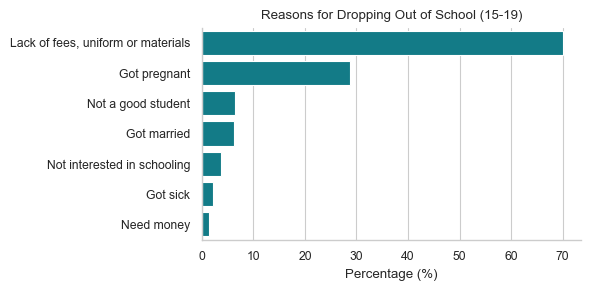

In [370]:
# What are some of the main reasons you are not in school?
count = df_sensitive.loc[(df_sensitive['attend_scol'] == 'Yes') & (df_sensitive['scol_status'] == 'Out of school')]

# Define dropout reasons
dropout_reasons = ['lack_fees', 'got_preg', 'got_married', 'got_sick', 'need_money', 'good_std', 'int_scol']

# Calculate count for each dropout reason
count_reasons_drop_out = count[dropout_reasons].apply(lambda col: (col == 1).sum()).to_frame(name='Count')
total_individuals = (count[dropout_reasons] == 1).any(axis=1).sum()

# Correct proportions by dividing by unique individuals
count_reasons_drop_out['Proportion'] = count_reasons_drop_out['Count'] / total_individuals

# Define mapping for dropout reasons with proper capitalization
dropout_labels = {
    'lack_fees': "Lack of fees, uniform or materials",
    'got_preg': "Got pregnant",
    'got_married': "Got married",
    'got_sick': "Got sick",
    'need_money': "Need money",
    'good_std': "Not a good student",
    'int_scol': "Not interested in schooling"
}

# Reset index to turn the index into a column
count_reasons_drop_out = count_reasons_drop_out.reset_index()

# Rename columns
count_reasons_drop_out.columns = ['Reason', 'Count', 'Proportion']

# Map the 'Reason' to descriptive labels
count_reasons_drop_out['Reason'] = count_reasons_drop_out['Reason'].map(dropout_labels).fillna("Unknown")

# Calculate percentage
count_reasons_drop_out['Percentage'] = (count_reasons_drop_out['Proportion'] * 100).round(1)

# Sort by Count descending
count_reasons_drop_out = count_reasons_drop_out.sort_values(by="Count", ascending=False)

# # Extract the first row details
first_row_id = count_reasons_drop_out.iloc[0]['Reason']
first_row_count = count_reasons_drop_out.iloc[0]['Count']
first_row_percentage = count_reasons_drop_out.iloc[0]['Proportion']

second_row_id = count_reasons_drop_out.iloc[1]['Reason']
second_row_count = count_reasons_drop_out.iloc[1]['Count']
second_row_percentage = count_reasons_drop_out.iloc[1]['Proportion']

# Display extracted values
print(f"The most common reason for dropping out is due to a {first_row_id} ({first_row_count} mentions).")
print(f"The second most common reason for dropping out is {second_row_id} ({second_row_count}  mentions).")

# Plot
plt.figure(figsize=(6, 3))
sns.barplot(x="Percentage", y="Reason", data=count_reasons_drop_out, color="#008b9a")
plt.xlabel("Percentage (%)")
plt.ylabel("")
plt.title("Reasons for Dropping Out of School (15-19)")
sns.despine(top=True, right=True)
plt.tight_layout()
plt.savefig(figures_path_15_19 + 'reasons_for_dropping_out_15_19.png')
plt.show()

In [ ]:
# If there was an opportunity for you to return to school, would you be willing to do so?
df = df_sensitive.loc[(df_sensitive['scol_status'] == 'Out of school') & (df_sensitive['got_preg'] == 1)]
count = df['return_scol'].value_counts()
percent = df['return_scol'].value_counts(normalize=True)

# Extract the proportion of 'yes' == 1 responses
count = count.get('Yes', 0)
percent = percent.get('Yes', 0)

print(f"Among the girls who mentioned pregnancy as the reason for dropping out, {count} would like to return to school if the opportunity arises.")

### Household situation

In [355]:
# Number of girls by wealth tertile
vulnerable_count = df_sensitive['wealth_tertile'].value_counts()
vulnerable_percent = df_sensitive['wealth_tertile'].value_counts(normalize=True)

# Extract the proportion of 'Low'
vulnerable_count = vulnerable_count.get('Low', 0)
vulnerable_percent = vulnerable_percent.get('Low', 0)

print(f"The proportion of girls living in low-income households is {vulnerable_percent:.1%} ({vulnerable_count}).")

The proportion of girls living in low-income households is 47.1% (423).


In [357]:
# Number of girls living in vulnerable households
vulnerable_count = df_sensitive['hh_vul'].value_counts()
vulnerable_percent = df_sensitive['hh_vul'].value_counts(normalize=True)

# Extract the proportion of 'yes' == 1 responses
vulnerable_count = vulnerable_count.get(1, 0)
vulnerable_percent = vulnerable_percent.get(1, 0)

print(f"The proportion of girls living in vulnerable households is {vulnerable_percent:.1%} ({vulnerable_count}).")

The proportion of girls living in vulnerable households is 11.5% (103).


In [359]:
# What is your main occupation, where you spend most of your time?
labels = {
    'PEASANT FARMER': "Peasant farmer",
    'SALARIED': "Salaried",
    'BUSINESS/COMMERCIAL': "Business/commercial",
    'CASUAL WORKER': "Casual worker",
    'HOUSE WIFE': "Housewife",
    'PUPIL/STUDENT/NO INCOME': "Pupil/student",
    'OTHER': "Other"
}

# Calculate raw counts for each occupation
raw_counts = df_sensitive["main_occup"].value_counts().reset_index()
raw_counts.columns = ["Occupation", "Count"]

# Map occupation codes to descriptive labels
raw_counts["Occupation"] = raw_counts["Occupation"].map(labels)

# Calculate percentage for each occupation
total = raw_counts["Count"].sum()
raw_counts["Percentage"] = (raw_counts["Count"] / total) * 100

# Sort the DataFrame by Count in descending order
raw_counts = raw_counts.sort_values(by="Count", ascending=False)

# Round the Percentage to two decimal places for clarity
raw_counts["Percentage"] = raw_counts["Percentage"].round(1)

# Reset index for a clean table
raw_counts.reset_index(drop=True, inplace=True)

# Extract the first row details
first_row_id = raw_counts.iloc[0]['Occupation']
first_row_count = raw_counts.iloc[0]['Count']
first_row_percentage = raw_counts.iloc[0]['Percentage']

second_row_id = raw_counts.iloc[1]['Occupation']
second_row_count = raw_counts.iloc[1]['Count']
second_row_percentage = raw_counts.iloc[1]['Percentage']

# Display
print(f"In response to the question ‘what is your main occupation, where you spend most of your time?’ most girls mentioned {first_row_id}, {first_row_percentage}% ({first_row_count}),")
print(f"followed by {second_row_id}, {second_row_percentage}% ({second_row_count}).")

In response to the question ‘what is your main occupation, where you spend most of your time?’ most girls mentioned Peasant farmer, 46.5% (418),
followed by Housewife, 15.1% (136).


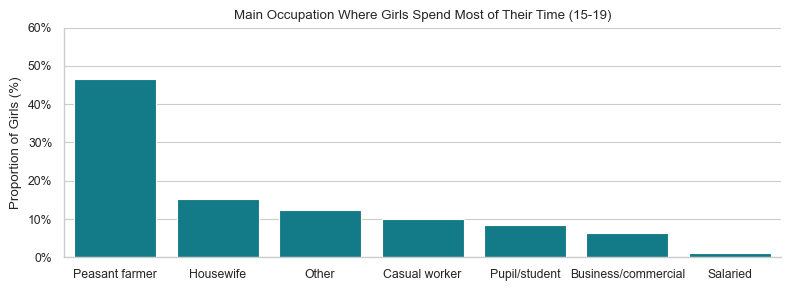

In [361]:
# Visualise main occupation
occup_counts = df_sensitive["main_occup"].value_counts(normalize=True).reset_index()
occup_counts.columns = ["Occupation", "Count"]

# Replace numerical values with category names
occup_counts["Occupation"] = occup_counts["Occupation"].map(labels)

# Convert proportion to percentage
occup_counts["Count"] *= 100

# Ensure Count column is numeric before sorting
occup_counts["Count"] = pd.to_numeric(occup_counts["Count"], errors='coerce')

# Sort values in descending order
occup_counts = occup_counts.sort_values(by="Count", ascending=False)

# Extract the ordered list of occupations
ordered_occupations = occup_counts["Occupation"]

# Plot
plt.figure(figsize=(8, 3))
sns.barplot(
    y="Count",
    x="Occupation",
    data=occup_counts,
    color="#008b9a",
    order=ordered_occupations
)

# Labels and title
plt.ylabel("Proportion of Girls (%)")
plt.xlabel("")
plt.title("Main Occupation Where Girls Spend Most of Their Time (15-19)")

# Remove top and right spines
sns.despine(top=True, right=True)

# Remove grid lines on y-axis
plt.grid(False, axis='x')

# Set custom x-ticks
plt.yticks(
    ticks=[0, 10, 20, 30, 40, 50, 60],
    labels=['0%', '10%', '20%', '30%', '40%', '50%', '60%']
)

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig(figures_path_15_19 + 'main_occupation_15_19.png')
plt.show()

In [ ]:
# Who do you currently live with?
person_labels = {
    'ALONE': "alone",
    'FRIENDS': "friends",
    'MOTHER ALONE': "mother alone",
    'FATHER ALONE': "father alone",
    'BOTH PARENTS': "both parents",
    'WITH OTHER RELATIVES': "with other relatives",
    'HUSBAND/PARTNER': "husband/partner"
}

# Calculate raw counts for each person_sex category
raw_counts = df_sensitive["who_live"].value_counts().reset_index()
raw_counts.columns = ["Person", "Count"]

# Map person_sex codes to descriptive labels
raw_counts["Person"] = raw_counts["Person"].map(person_labels)

# Calculate percentage for each person category
total = raw_counts["Count"].sum()
raw_counts["Percentage"] = (raw_counts["Count"] / total) * 100

# Sort the DataFrame by Count in descending order
raw_counts = raw_counts.sort_values(by="Count", ascending=False)

# Round the Percentage to one decimal place for clarity
raw_counts["Percentage"] = raw_counts["Percentage"].round(1)

# Reset index for a clean table
raw_counts.reset_index(drop=True, inplace=True)

# Extract the first row details
first_row_id = raw_counts.iloc[0]['Person']
first_row_count = raw_counts.iloc[0]['Count']
first_row_percentage = raw_counts.iloc[0]['Percentage']

# Extract the second row details
second_row_id = raw_counts.iloc[1]['Person']
second_row_count = raw_counts.iloc[1]['Count']
second_row_percentage = raw_counts.iloc[1]['Percentage']

# Display extracted values
print(f"Girls mainly live with their {first_row_id}, {first_row_percentage}% ({first_row_count}), and then {second_row_id}, {second_row_percentage}% ({second_row_count}).")

### Marriage

In [390]:
# Have you ever been married?
been_marriage_count = df_insensitive['been_married_binary'].value_counts()
been_marriage_percent = df_insensitive['been_married_binary'].value_counts(normalize=True)

# Extract the proportion of 'yes' == 1 responses
been_marriage_count = been_marriage_count.get(1, 0)
been_marriage_percent = been_marriage_percent.get(1, 0)

# Are you currently married?
marriage_count = df_insensitive['current_married_binary'].value_counts()
marriage_percent = df_insensitive['current_married_binary'].value_counts(normalize=True)

# Extract the proportion of 'yes' == 1 responses
marriage_count = marriage_count.get(1, 0)
marriage_percent = marriage_percent.get(1, 0)

print(f"The proportion of girls who have ever been married is {been_marriage_percent:.1%} ({been_marriage_count}) and the proportion of girls currently married is {marriage_percent:.1%} ({marriage_count}).")

The proportion of girls who have ever been married is 64.1% (1154) and the proportion of girls currently married is 50.1% (901).


In [392]:
df_insensitive['current_married'].value_counts()

current_married
MARRIED/UNION                      901
IN RELATIONSHIP BUT NOT MARRIED    354
NEVER MARRIED                      292
DIVORCED/SEPARATED                 249
WIDOWED                              4
Name: count, dtype: int64

Most girls who married and experienced pregnancy between 10-14 years got married at 0    18
Name: age_marry, dtype: int64 years.


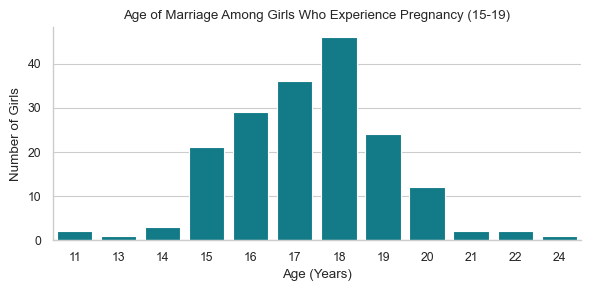

In [394]:
# How old were you when you first got married?
df_pro = df_insensitive[df_insensitive['been_married_binary'] == 1].copy()

# Remove rows with missing age_marry before converting to int
df_pro = df_pro[df_pro['age_marry'].notna()].copy()
df_pro['age_marry'] = df_pro['age_marry'].astype(int)
df_pro = df_pro[df_pro['age_completed'] >= 24]

# Age of Marriage Among Girls Who Experience Pregnancy
mean_age = df_pro['age_marry'].mode().round()
print(f"Most girls who married and experienced pregnancy between 10-14 years got married at {mean_age} years.")

plt.figure(figsize=(6, 3))
ax = sns.countplot(x='age_marry', data=df_pro, color='#008b9a')
plt.xlabel("Age (Years)")
plt.ylabel("Number of Girls")
plt.title("Age of Marriage Among Girls Who Experience Pregnancy (15-19)")
sns.despine(top=True, right=True)



plt.tight_layout()
plt.savefig(figures_path_15_19 + 'age_marriage_15_19.png', dpi=300)
plt.show()

In [ ]:
(df_pro['age_marry'] == 11).sum()

### Sexual Debut

In [ ]:
# Age of Sexual Debut Among Girls Who Experience Pregnancy
mean = df_insensitive.sex_age.mean().round()

print(f"On average girls who fall pregnant between 15 and 19 had their sexual debut at {mean} years.")

df_fig = df_insensitive[df_insensitive['sex_age'] >= 10]
plt.figure(figsize=(8, 5))
plt.hist(df_fig['sex_age'].dropna(), bins=9, color='#008b9a')

plt.xlabel("Age (Years)")
plt.ylabel("Number of Girls")
plt.title("Age of Sexual Debut Among Girls Who Experience Pregnancy (15-19)", fontsize=12)
sns.despine(top=True, right=True)
plt.grid(False, axis='x')

plt.tight_layout()
plt.savefig(figures_path_15_19 + 'age_sexual_debut_preg_15_19.png', dpi=300)
plt.show()

In [ ]:
# Distribution of Time Between Sexual Debut and Pregnancy
df_insensitive['time_to_pregnancy'] = df_insensitive['age_preg'] - df_insensitive['sex_age']
mean = df_insensitive['time_to_pregnancy'].mean().round()
df_fig = df_insensitive[df_insensitive['time_to_pregnancy'] <= 8]
print(f"These girls tend to fall pregnant within {mean} year of sexual debut.")

plt.figure(figsize=(8, 5))
plt.hist(df_fig['time_to_pregnancy'].dropna(), bins=8, color='#008b9a')

plt.xlabel("Years Between First Sex and First Pregnancy")
plt.ylabel("Number of Girls")
plt.title("Distribution of Time Between Sexual Debut and Pregnancy (15-19)", fontsize=12)
sns.despine(top=True, right=True)
plt.grid(False, axis='x')

plt.tight_layout()
plt.savefig(figures_path_15_19 + 'time_between_sexual_debut_preg_15_19.png', dpi=300)
plt.show()

In [ ]:
# Which person did you have sex with for the first time?
person_labels = {
    1.00: "Boyfriend",
    2.00: "Husband",
    3.00: "Stranger",
    4.00: "Brother",
    5.00: "Teacher",
    6.00: "Uncle",
    7.00: "Father",
    8.00: "Other relative"
}

# Calculate raw counts for each person_sex category
raw_counts = df_insensitive["person_sex"].value_counts().reset_index()
raw_counts.columns = ["Person", "Count"]

# Map person_sex codes to descriptive labels
raw_counts["Person"] = raw_counts["Person"].map(person_labels)

# Calculate percentage for each person category
total = raw_counts["Count"].sum()
raw_counts["Percentage"] = (raw_counts["Count"] / total) * 100

# Sort the DataFrame by Count in descending order
raw_counts = raw_counts.sort_values(by="Count", ascending=False)

# Optional: Round the Percentage to one decimal place for clarity
raw_counts["Percentage"] = raw_counts["Percentage"].round(1)

# Reset index for a clean table
raw_counts.reset_index(drop=True, inplace=True)

# Extract the first row details
first_row_id = raw_counts.iloc[0]['Person']
first_row_count = raw_counts.iloc[0]['Count']
first_row_percentage = raw_counts.iloc[0]['Percentage']

# Extract the second row details
second_row_id = raw_counts.iloc[1]['Person']
second_row_count = raw_counts.iloc[1]['Count']
second_row_percentage = raw_counts.iloc[1]['Percentage']

# Display extracted values
print(f"The most cited sexual partner at sexual debut was a {first_row_id}, {first_row_percentage}% ({first_row_count}).")
print(f"The second most cited sexual partner was a {second_row_id}, {second_row_percentage}% ({second_row_count}).")

In [ ]:
# Visualise Which person did you have sex with for the first time?
person_sex_counts = df_insensitive["person_sex"].value_counts(normalize=True).reset_index()
person_sex_counts.columns = ["Person", "Count"]

# Convert proportion to percentage
person_sex_counts["Count"] *= 100

# Replace numerical values with category names
person_sex_counts["Person"] = person_sex_counts["Person"].map(person_labels)

# Filter out NaN values (if any exist) and get the top 3
top_3 = person_sex_counts.dropna().nlargest(3, "Count")

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x="Person", y="Count", data=top_3, color="#008b9a")

# Labels and title
plt.ylabel("Proportion of Girls")
plt.xlabel("")
plt.title("Top 3 Sexual Partners of First Sexual Encounter", fontsize=12)
sns.despine(top=True, right=True)
plt.grid(False, axis='x')
plt.yticks(ticks=[0, 20, 40, 60, 80], labels=['0%', '20%', '40%', '60%', '80%']) 

plt.tight_layout()
plt.savefig(figures_path_15_19 + 'first_sexual_partner_15_19.png', dpi=300)
plt.show()

In [ ]:
# The first time you had sexual intercourse with someone; would you say you were willing, somewhat willing or not willing at all?
willing_count = df_insensitive['will_sex_binary'].value_counts()
willing_percent = df_insensitive['will_sex_binary'].value_counts(normalize=True)

# Extract the proportion of 'yes' == 1 responses
willing_count = willing_count.get(1.00, 0)
willing_percent = willing_percent.get(1.00, 0)

print(f"The proportion of girls who reported that they were willing the first time they had sex was {willing_percent:.1%} ({willing_count}), the remainder of girls reported that they were not willing.")

In [ ]:
# Willingness by type of partner
willing_mapping = {1.00: "Willing", 0.00: "Not willing"}

# Create a cross-tabulation of willingness vs. type of sexual partner
willing_vs_partner = pd.crosstab(
    df_insensitive['will_sex_binary'].map(willing_mapping),
    df_insensitive['person_sex'].map(person_labels)
)

# Filter for the top three person types: Boyfriend, Husband, Stranger
top3 = willing_vs_partner[['Boyfriend', 'Husband', 'Stranger']]

# Convert counts to percentages column-wise
top3_percent = top3.div(top3.sum(axis=0), axis=1) * 100
top3_percent = top3_percent.round(0)

top3_percent

In [ ]:
# The first time you had sexual intercourse with someone; did you or your partner do anything to prevent pregnancy?
anything_count = df_insensitive['do_anything'].value_counts()
anything_percent = df_insensitive['do_anything'].value_counts(normalize=True)

# Extract the proportion of 'yes' == 1 responses
anything_count = anything_count.get(1.00, 0)
anything_percent = anything_percent.get(1.00, 0)

print(f"The proportion of girls who used pregnancy prevention during their first sexual encounter was {anything_percent:.1%} ({anything_count}).")

# The first time you had sexual intercourse, were you under the influence of alcohol or drugs?
influence_count = df_insensitive['under_influe'].value_counts()
influence_percent = df_insensitive['under_influe'].value_counts(normalize=True)

# Extract the proportion of 'yes' == 1 responses
influence_count = influence_count.get(2.00, 0)
influence_percent = influence_percent.get(2.00, 0)

print(f"Most girls reported that they were not under the influence of alcohol or drugs during their first sexual encounter, {influence_percent:.1%} ({influence_count}).")

In [ ]:
# The first time you had sex, what did you use to avoid a pregnancy?
count = df_insensitive.loc[(df_insensitive['do_anything'] == 1.00)]

contraception = ['male_condom', 'female_condom', 'iud_coil', 'pill', 'withdrawal', 'implant', 'injection', 'emergency']

# Calculate count of '1's for each contraception
count_contraception = count[contraception].apply(lambda col: (col == 1).sum()).to_frame(name='Count')

# Calculate the total number of unique individuals who reported at least one contraception
total_individuals = (count[contraception] == 1).any(axis=1).sum()

# Correct proportions by dividing by unique individuals
count_contraception['Proportion'] = ((count_contraception['Count'] / total_individuals) * 100).round(0)

count_contraception = count_contraception.sort_values(by='Proportion', ascending=False)

# Extract the first row details
first_row_id = count_contraception.index[0]
first_row_count = count_contraception.iloc[0]['Count']
first_row_percentage = count_contraception.iloc[0]['Proportion']

# Display extracted values
print(f"The most reported pregnancy prevention methods were {first_row_id} used by {first_row_percentage}% ({first_row_count}).")